# 00 — Exploratory Data Analysis & Data Preparation

**KITTI Object Detection Dataset — Edge Case Project**

This notebook:
1. Downloads the KITTI dataset via Ultralytics to local Colab storage (`/content/`)
2. Performs EDA (class distribution, bounding boxes, image dimensions)
3. Verifies YOLO format structure
4. Saves the baseline dataset to Google Drive (mounted only at the end)

**I/O Protocol:** All processing on `/content/` (local Colab disk). Google Drive used only at the very end.

## 0. Environment Setup

In [1]:
%%capture
!pip install ultralytics matplotlib seaborn pandas opencv-python-headless Pillow tqdm

In [2]:
import os
import glob
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

# Reproducibility
random.seed(42)
np.random.seed(42)

# ---------- Paths (all on local Colab disk) ----------
BASE_DIR = "/content/datasets"
KITTI_DIR = os.path.join(BASE_DIR, "kitti")
os.makedirs(BASE_DIR, exist_ok=True)

# KITTI class names (Ultralytics YOLO format, class_id starts at 0)
CLASS_NAMES = {
    0: "Car", 1: "Van", 2: "Truck", 3: "Pedestrian",
    4: "Person_sitting", 5: "Cyclist", 6: "Tram", 7: "Misc"
}

print(f"Working directory: {BASE_DIR}")
print(f"Classes: {list(CLASS_NAMES.values())}")

Working directory: /content/datasets
Classes: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']


---
## 1. Download KITTI Dataset

Uses the Ultralytics built-in dataset manager to download KITTI (~390 MB) directly to `/content/datasets/`.

In [3]:
import ultralytics

# Point Ultralytics to local Colab storage
ultralytics.settings.update({"datasets_dir": BASE_DIR})

from ultralytics.data.utils import check_det_dataset

# Download and prepare KITTI (auto-downloads if not present)
data_dict = check_det_dataset("kitti.yaml")

kitti_root = data_dict["path"]
print(f"Dataset root: {kitti_root}")
print(f"Train path:   {data_dict['train']}")
print(f"Val path:     {data_dict['val']}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'kitti.yaml' images not found, missing path '/content/datasets/kitti/images/val'
Unzipping /content/datasets/kitti.zip to /content/datasets/kitti...: 100% ━━━━━━━━━━━━ 14969/14969 3.1Kfiles/s 4.8s
Dataset download success ✅ (9.1s), saved to /content/datasets

Dataset root: /content/datasets/kitti
Train path:   /content/datasets/kitti/images/train
Val path:     /content/datasets/kitti/images/val


In [4]:
# Resolve directory paths
train_img_dir = os.path.join(kitti_root, "images", "train")
val_img_dir   = os.path.join(kitti_root, "images", "val")
train_lbl_dir = os.path.join(kitti_root, "labels", "train")
val_lbl_dir   = os.path.join(kitti_root, "labels", "val")

for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    count = len(os.listdir(d)) if os.path.isdir(d) else 0
    print(f"{os.path.relpath(d, BASE_DIR):40s} -> {count:>5} files")

kitti/images/train                       ->  5985 files
kitti/images/val                         ->  1496 files
kitti/labels/train                       ->  5985 files
kitti/labels/val                         ->  1496 files


---
## 2. Exploratory Data Analysis

### 2.1 Class Distribution

In [5]:
def parse_yolo_labels(label_dir):
    """Parse all YOLO label files into a DataFrame."""
    records = []
    for lbl_file in sorted(glob.glob(os.path.join(label_dir, "*.txt"))):
        fname = os.path.basename(lbl_file)
        with open(lbl_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])
                    records.append({
                        "file": fname, "class_id": cls_id,
                        "cx": cx, "cy": cy, "w": w, "h": h
                    })
    return pd.DataFrame(records)


train_labels = parse_yolo_labels(train_lbl_dir)
val_labels   = parse_yolo_labels(val_lbl_dir)
all_labels   = pd.concat([train_labels, val_labels], ignore_index=True)

all_labels["class_name"] = all_labels["class_id"].map(CLASS_NAMES)

print(f"Total annotations: {len(all_labels):,}")
print(f"  Train: {len(train_labels):,}  |  Val: {len(val_labels):,}")
print("\nPer-class counts:")
print(all_labels["class_name"].value_counts().to_string())

Total annotations: 40,570
  Train: 32,442  |  Val: 8,128

Per-class counts:
class_name
Car               28742
Pedestrian         4487
Van                2914
Cyclist            1627
Truck              1094
Misc                973
Tram                511
Person_sitting      222


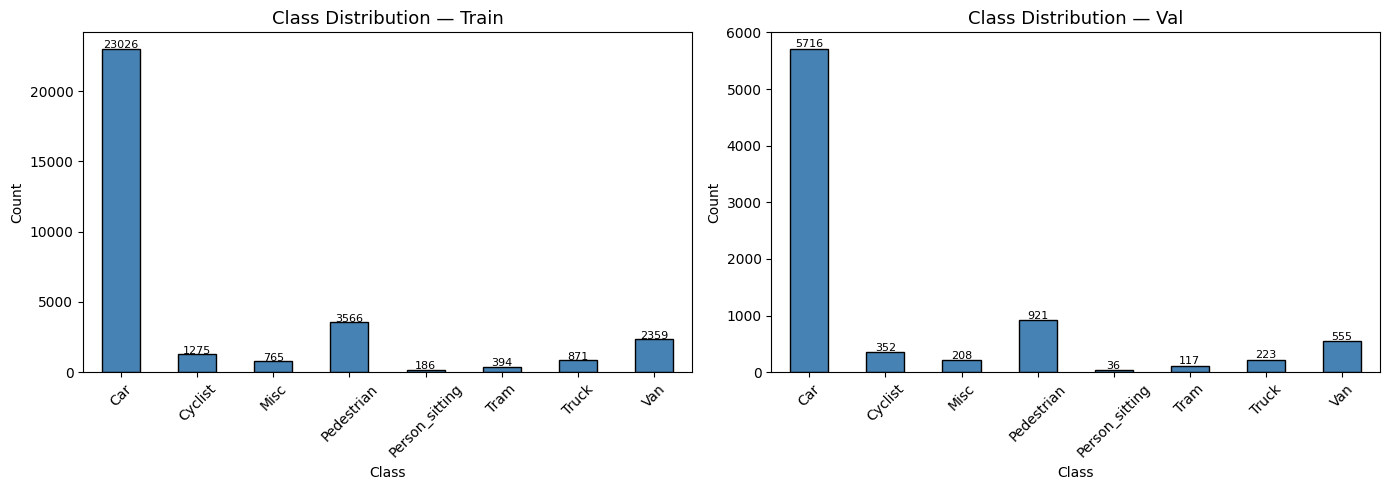

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(train_labels, "Train"), (val_labels, "Val")]):
    df_named = df.copy()
    df_named["class_name"] = df_named["class_id"].map(CLASS_NAMES)
    counts = df_named["class_name"].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Class Distribution — {title}", fontsize=13)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    for i, v in enumerate(counts):
        ax.text(i, v + 20, str(v), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Bounding Box Visualization

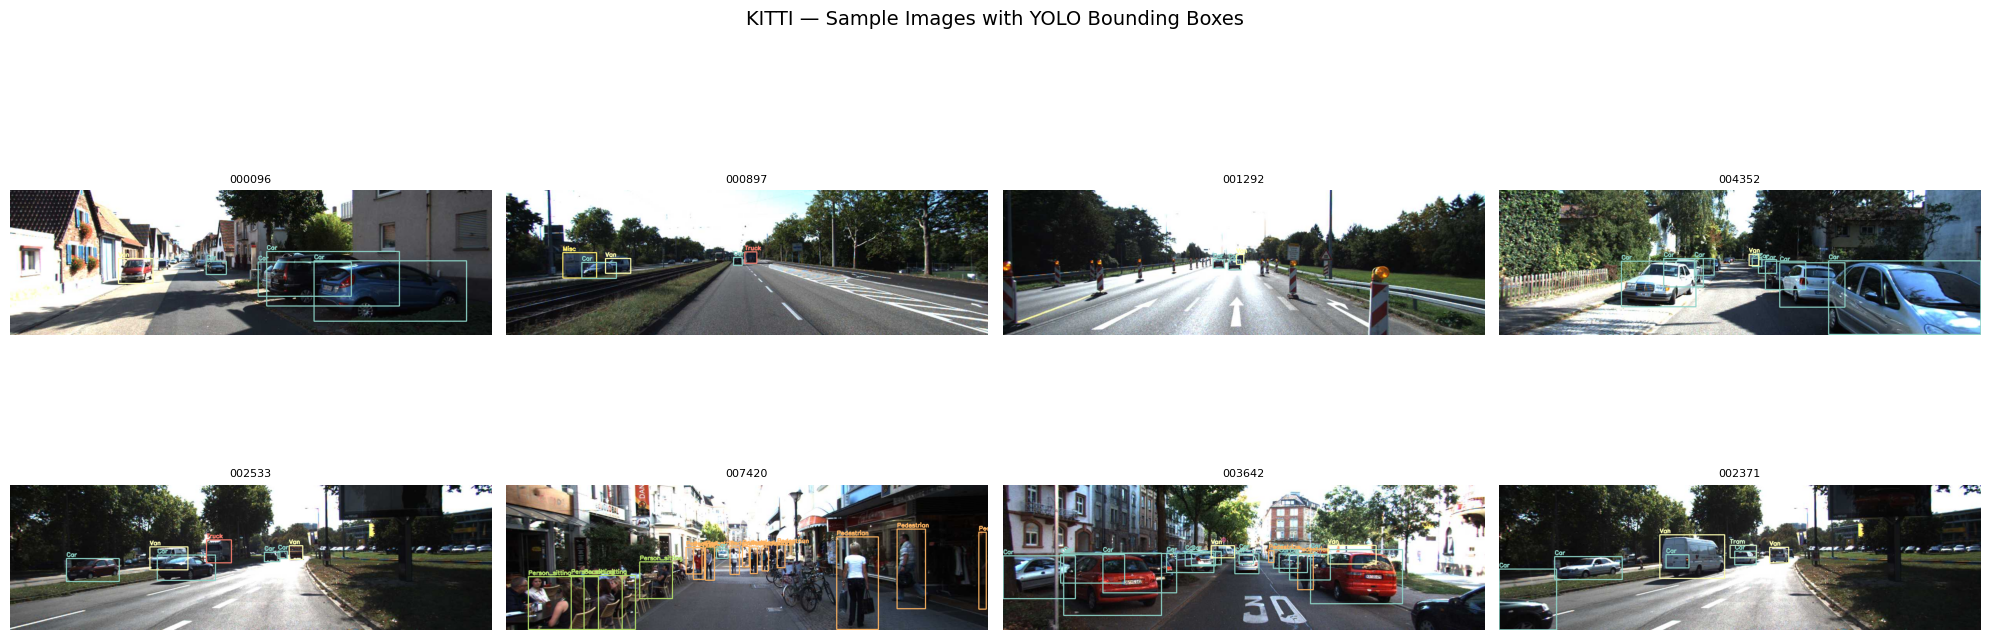

In [7]:
def draw_yolo_bboxes(img_path, lbl_path, class_names):
    """Draw YOLO bounding boxes on an image."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not os.path.exists(lbl_path):
        return img

    palette = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
    colors = (palette[:, :3] * 255).astype(int)

    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])

            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)

            c = tuple(map(int, colors[cls_id % len(colors)]))
            cv2.rectangle(img, (x1, y1), (x2, y2), c, 2)
            cv2.putText(img, class_names.get(cls_id, "?"),
                        (x1, max(y1 - 5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 2)
    return img


# Show 8 random samples
sample_imgs = sorted(glob.glob(os.path.join(train_img_dir, "*")))
random.shuffle(sample_imgs)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, img_path in zip(axes.flat, sample_imgs[:8]):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(train_lbl_dir, stem + ".txt")
    img = draw_yolo_bboxes(img_path, lbl_path, CLASS_NAMES)
    ax.imshow(img)
    ax.set_title(stem, fontsize=8)
    ax.axis("off")

plt.suptitle("KITTI — Sample Images with YOLO Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.savefig("/content/bbox_samples.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Image Dimensions

Scanning:   0%|          | 0/5985 [00:00<?, ?it/s]

Width  — min: 1224, max: 1242, mean: 1240
Height — min: 370, max: 376, mean: 374
Typical aspect ratio: 3.31:1


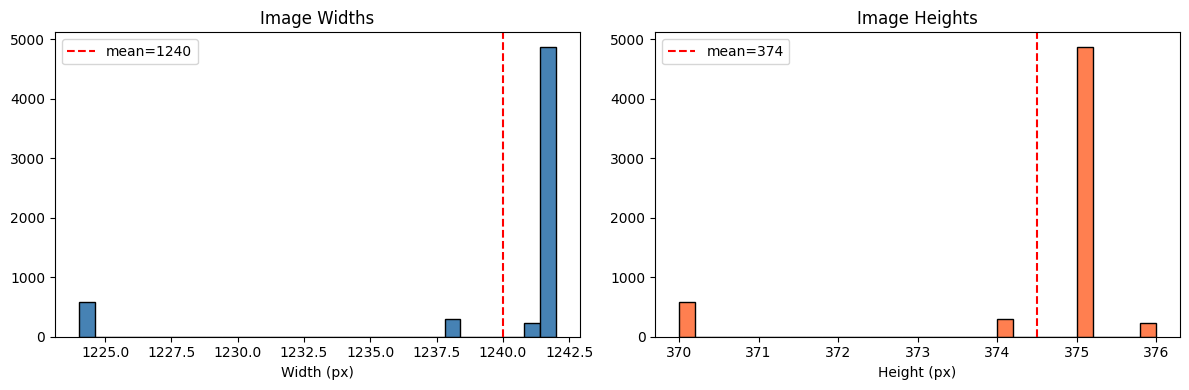

In [8]:
widths, heights = [], []
for img_path in tqdm(glob.glob(os.path.join(train_img_dir, "*")), desc="Scanning"):
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Typical aspect ratio: {np.mean(widths)/np.mean(heights):.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Image Widths")
axes[0].set_xlabel("Width (px)")
axes[0].axvline(np.mean(widths), color="red", linestyle="--", label=f"mean={np.mean(widths):.0f}")
axes[0].legend()

axes[1].hist(heights, bins=30, color="coral", edgecolor="black")
axes[1].set_title("Image Heights")
axes[1].set_xlabel("Height (px)")
axes[1].axvline(np.mean(heights), color="red", linestyle="--", label=f"mean={np.mean(heights):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Bounding Box Size Distribution

/tmp/ipykernel_355/3879424664.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="class_name", y="area", order=order,


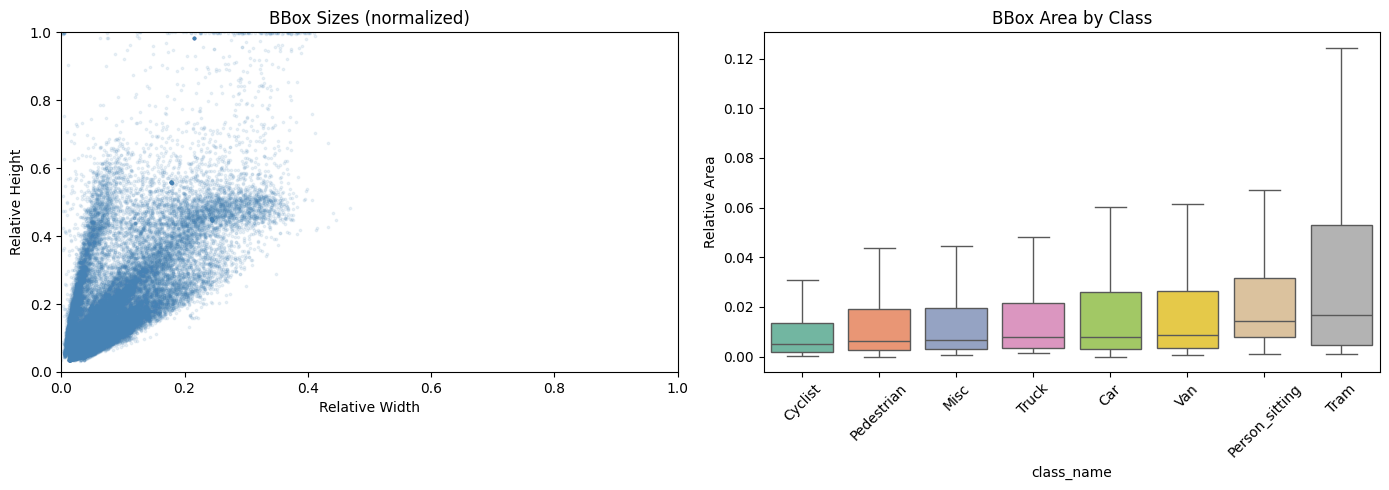

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: relative bbox sizes
axes[0].scatter(all_labels["w"], all_labels["h"], alpha=0.1, s=3, c="steelblue")
axes[0].set_xlabel("Relative Width")
axes[0].set_ylabel("Relative Height")
axes[0].set_title("BBox Sizes (normalized)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Box plot: area by class
all_labels["area"] = all_labels["w"] * all_labels["h"]
plot_df = all_labels[["class_name", "area"]].copy()
order = plot_df.groupby("class_name")["area"].median().sort_values().index
sns.boxplot(data=plot_df, x="class_name", y="area", order=order,
            ax=axes[1], showfliers=False, palette="Set2")
axes[1].set_title("BBox Area by Class")
axes[1].set_ylabel("Relative Area")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("/content/bbox_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. YOLO Format Verification

In [10]:
def verify_yolo_structure(img_dir, lbl_dir, split_name):
    """Verify 1:1 image-label correspondence and label format."""
    img_stems = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
    lbl_stems = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)
                 if f.endswith(".txt")}

    missing = img_stems - lbl_stems
    orphans = lbl_stems - img_stems

    print(f"=== {split_name} ===")
    print(f"  Images: {len(img_stems)}  |  Labels: {len(lbl_stems)}")
    print(f"  Missing labels: {len(missing)}")
    print(f"  Orphan labels:  {len(orphans)}")

    # Validate label format (check first 200 files)
    errors = 0
    checked = 0
    for lbl_file in sorted(glob.glob(os.path.join(lbl_dir, "*.txt")))[:200]:
        checked += 1
        with open(lbl_file) as f:
            for i, line in enumerate(f):
                parts = line.strip().split()
                if len(parts) < 5:
                    errors += 1
                    continue
                cls = int(parts[0])
                vals = [float(v) for v in parts[1:5]]
                if cls not in CLASS_NAMES:
                    errors += 1
                if not all(0 <= v <= 1.0 for v in vals):
                    errors += 1

    print(f"  Format errors (first {checked} files): {errors}")
    ok = len(missing) == 0 and errors == 0
    print(f"  Status: {'PASS' if ok else 'ISSUES FOUND'}")
    return ok


ok_train = verify_yolo_structure(train_img_dir, train_lbl_dir, "Train")
print()
ok_val = verify_yolo_structure(val_img_dir, val_lbl_dir, "Val")
print(f"\nAll checks passed: {ok_train and ok_val}")

=== Train ===
  Images: 5985  |  Labels: 5985
  Missing labels: 0
  Orphan labels:  0
  Format errors (first 200 files): 0
  Status: PASS

=== Val ===
  Images: 1496  |  Labels: 1496
  Missing labels: 0
  Orphan labels:  0
  Format errors (first 200 files): 0
  Status: PASS

All checks passed: True


---
## 4. Save Baseline Dataset to Google Drive

Mount Google Drive and copy the KITTI dataset + EDA artifacts.

In [11]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_OUT = "/content/drive/MyDrive/Autonomous_Car"
os.makedirs(DRIVE_OUT, exist_ok=True)

# Copy KITTI baseline
dst_kitti = os.path.join(DRIVE_OUT, "kitti_baseline")
if not os.path.exists(dst_kitti):
    print("Copying KITTI dataset to Drive (this may take a few minutes)...")
    shutil.copytree(kitti_root, dst_kitti)
    print("Done.")
else:
    print(f"Baseline already exists at {dst_kitti}, skipping copy.")

# Copy EDA artifacts
for png in glob.glob("/content/*.png"):
    shutil.copy2(png, DRIVE_OUT)
    print(f"Copied {os.path.basename(png)}")

print(f"\nAll saved to: {DRIVE_OUT}")
print("Contents:")
for item in sorted(os.listdir(DRIVE_OUT)):
    full = os.path.join(DRIVE_OUT, item)
    if os.path.isdir(full):
        print(f"  [DIR]  {item}")
    else:
        size_mb = os.path.getsize(full) / 1e6
        print(f"  [FILE] {item} ({size_mb:.1f} MB)")

Mounted at /content/drive
Copying KITTI dataset to Drive (this may take a few minutes)...
Done.
Copied class_distribution.png
Copied bbox_samples.png
Copied bbox_analysis.png
Copied image_dimensions.png

All saved to: /content/drive/MyDrive/Autonomous_Car
Contents:
  [DIR]  Notebooks
  [FILE] bbox_analysis.png (0.2 MB)
  [FILE] bbox_samples.png (2.2 MB)
  [FILE] class_distribution.png (0.1 MB)
  [FILE] image_dimensions.png (0.0 MB)
  [DIR]  kitti_baseline


---
**Notebook complete.** The KITTI dataset has been downloaded, explored, verified in YOLO format, and saved to Google Drive.

**Next:** `01_Generation_and_Evaluation.ipynb`